# **1. Perkenalan Dataset**



Proyek ini menggunakan dataset Bank Transaction Dataset for Fraud Detection. Dataset ini diambil dari Kaggle yang dapat diakses melalui : https://www.kaggle.com/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection. Berikut informasi mengenai datasetnya :
- Nama Dataset : Bank Transaction Dataset for Fraud Detection
- Jumlah Data  : 2,512
- Jumlah Fitur : 16

# **2. Import Library**

**impor library yang digunakan pada proyek**

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# **3. Memuat Dataset**

**Load dataset**

In [62]:
url = "https://raw.githubusercontent.com/abdlsykr/portfolio/refs/heads/main/Dicoding/Belajar_Machine_Learning_Untuk_Pemula/bank_transactions_data_2.csv"
df = pd.read_csv(url)

In [63]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


# **4. Exploratory Data Analysis (EDA)**

1. Univariate Analysis :
    - Melihat Statistik Deskriptif
    - Melihat Missing Value

2. Multivariate Analysis :
    - Korelasi antar fitur menggunakan heatmap

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [65]:
df.isnull().sum()

,0
TransactionID,0
AccountID,0
TransactionAmount,0
TransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


In [66]:
'''
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns  # Pilih hanya kolom numerik
corr_matrix = df[numeric_columns].corr()  # Hitung korelasi hanya untuk kolom numerik

df['TransactionAmount'].plot(kind='hist', bins=50, title='Distribution of Transaction Amount')
'''


"\nnumeric_columns = df.select_dtypes(include=['float64', 'int64']).columns  # Pilih hanya kolom numerik\ncorr_matrix = df[numeric_columns].corr()  # Hitung korelasi hanya untuk kolom numerik\n\ndf['TransactionAmount'].plot(kind='hist', bins=50, title='Distribution of Transaction Amount')\n"

Menentukan Data Numerik

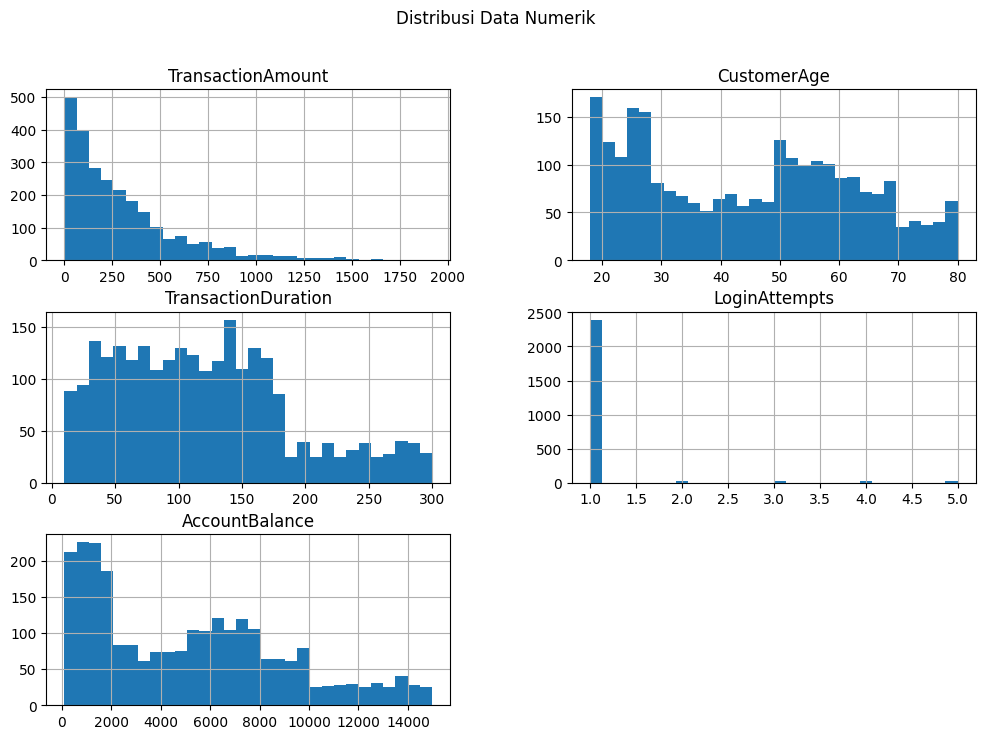

In [67]:
numerical_columns = [
    'TransactionAmount',
    'CustomerAge',
    'TransactionDuration',
    'LoginAttempts',
    'AccountBalance'
]

df[numerical_columns].hist(bins=30, figsize=(12, 8))
plt.suptitle("Distribusi Data Numerik")
plt.show()

Multivariate Analysis dengan Correlation Matrix

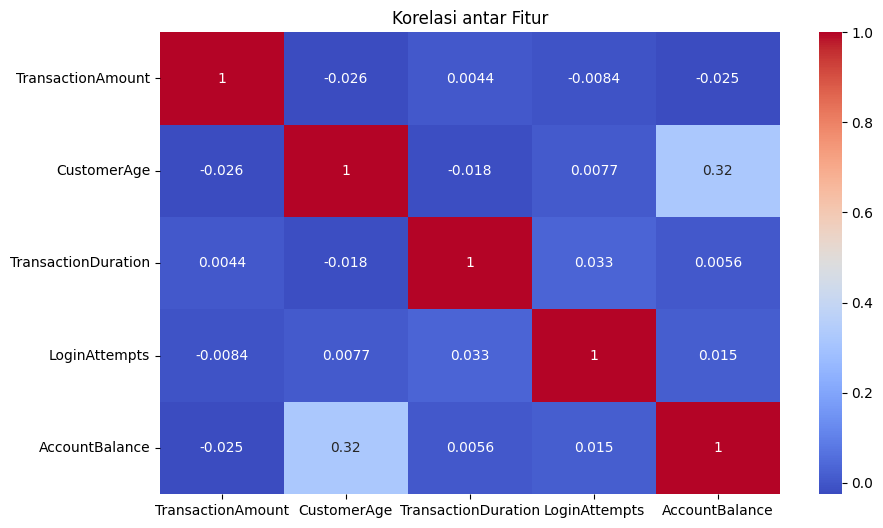

In [68]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap='coolwarm')
plt.title("Korelasi antar Fitur")
plt.show()

# **5. Data Preprocessing**

In [69]:
df = df.drop_duplicates()

In [70]:
df_cleaned = df.drop(columns=[
    'TransactionID', 'AccountID', 'TransactionDate',
    'DeviceID', 'IP Address', 'MerchantID', 'PreviousTransactionDate'
])


In [71]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionAmount    2512 non-null   float64
 1   TransactionType      2512 non-null   object 
 2   Location             2512 non-null   object 
 3   Channel              2512 non-null   object 
 4   CustomerAge          2512 non-null   int64  
 5   CustomerOccupation   2512 non-null   object 
 6   TransactionDuration  2512 non-null   int64  
 7   LoginAttempts        2512 non-null   int64  
 8   AccountBalance       2512 non-null   float64
dtypes: float64(2), int64(3), object(4)
memory usage: 176.8+ KB


In [72]:
#Encoding Data Kategorikal
df_encoded = pd.get_dummies(df_cleaned, drop_first=True)

In [73]:
#Standarisasi data numerik
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_encoded)

# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Text(0, 0.5, 'Inertia')

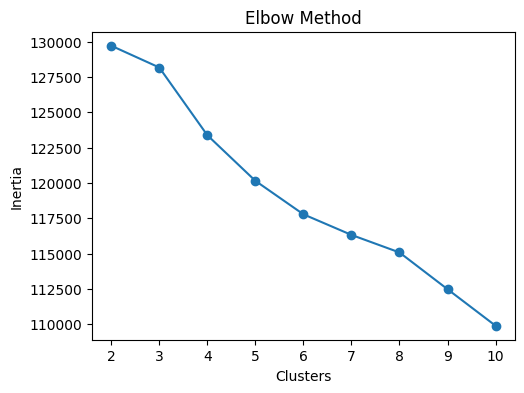

In [74]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_data, kmeans.labels_))

plt.figure(figsize=(12, 4))

# Elbow
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("Inertia")

nilai kluster yang paling baik adalah 4

In [75]:
kmeans = KMeans(n_clusters=4) #Disini pilih 4 berdasarkan elbow method

In [76]:
kmeans.fit(scaled_data)  # Melatih model hanya pada kolom numerik
df['Cluster'] = kmeans.fit_predict(scaled_data)

## **b. Evaluasi Model Clustering**

In [77]:
#Hasil sebelum elbow method
cluster_summary = df.groupby('Cluster')[numerical_columns].mean()
print(cluster_summary)

         TransactionAmount  CustomerAge  TransactionDuration  LoginAttempts  \
Cluster                                                                       
0               369.511957    38.347826           124.195652       1.130435   
1               312.303665    23.054348           120.299689       1.110248   
2               295.312003    65.299663           117.427609       1.127946   
3               288.289194    46.271987           120.200326       1.130293   

         AccountBalance  
Cluster                  
0           5369.317826  
1           1556.641630  
2           4530.296953  
3           7252.986018  


In [78]:
# Hitung silhouette score
sil_score = silhouette_score(scaled_data, kmeans.labels_)

# Tampilkan hasilnya
print("Silhouette Score:", sil_score)

Silhouette Score: 0.05281688025813681


## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

**Catatan**

Jika tidak dilakukan bisa dihapus saja keterangannya

In [79]:
#Type your code here

## **d. Visualisasi Hasil Clustering**

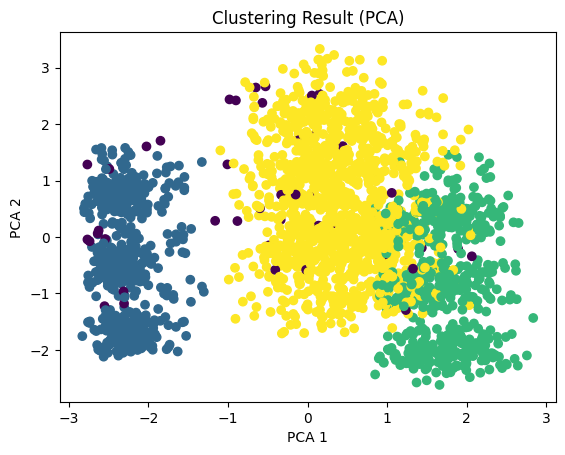

In [80]:
#Visualisasi dengan PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df['Cluster'], cmap='viridis')
plt.title("Clustering Result (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

**Catatan:**

Disini silahkan tampilkan hasil clusteringnya

## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan Hasil Label Cluster ke DataFrame**
Setelah mendapatkan hasil clustering, kita tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi.

```python
df_normalized['Cluster'] = model_kmeans.labels_
```

Lakukan Inverse Transform pada feature yang sudah dilakukan Labelisasi dan Standararisasi. Berikut code untuk melakukannya:
label_encoder.inverse_transform(X_Selected[['Fitur']])

Lalu masukkan ke dalam kolom dataset asli atau membuat dataframe baru
```python
df_normalized['Fitur'] = label_encoder.inverse_transform(df_normalized[['Fitur']])
```
Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
```python
df_original['Fitur'] = df_normalized['Fitur']
```

In [81]:
df['Cluster'] = kmeans.labels_

In [82]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Cluster
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08,3
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35,3
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04,1
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06,1
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39,1


### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Inverse Transform untuk Data yang Distandarisasi
Jika data numerik telah dinormalisasi menggunakan StandardScaler atau MinMaxScaler, kita bisa mengembalikannya ke skala asli:
```python
df_normalized[['Fitur_Numerik']] = scaler.inverse_transform(df_normalized[['Fitur_Numerik']])
```

Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

In [83]:
cluster_analysis = df.groupby('Cluster')[['TransactionAmount', 'AccountBalance', 'CustomerAge']].mean()
print(cluster_analysis)

         TransactionAmount  AccountBalance  CustomerAge
Cluster                                                
0               369.511957     5369.317826    38.347826
1               312.303665     1556.641630    23.054348
2               295.312003     4530.296953    65.299663
3               288.289194     7252.986018    46.271987


# Analisis Karakteristik Cluster dari Model KMeans

Berikut adalah analisis karakteristik untuk setiap cluster yang dihasilkan dari model KMeans.

## Cluster 0:
- **Rata-rata Jumlah Transaksi**: 369.51
- **Rata-rata Saldo Akun**: 5369.32
- **Rata-rata Usia Pelanggan**: 38.35 tahun
- **Analisis:** Cluster ini terdiri dari pelanggan dengan jumlah transaksi yang cukup tinggi dan saldo akun yang juga tinggi. Pelanggan dalam cluster ini umumnya berada pada usia yang relatif matang, dengan kapasitas finansial yang kuat dan aktif dalam bertransaksi dengan nilai yang cukup besar.

## Cluster 1:
- **Rata-rata Jumlah Transaksi**: 312.30
- **Rata-rata Saldo Akun**: 1556.64
- **Rata-rata Usia Pelanggan**: 23.05 tahun
- **Analisis:** Cluster ini berisi pelanggan yang lebih muda dengan transaksi yang lebih rendah dibandingkan dengan cluster lainnya. Mereka memiliki saldo akun yang lebih kecil, yang menunjukkan mereka mungkin berada pada tahap awal karir atau kehidupan finansial mereka. Meskipun demikian, mereka cukup aktif dalam bertransaksi.

## Cluster 2:
- **Rata-rata Jumlah Transaksi**: 295.31
- **Rata-rata Saldo Akun**: 4530.30
- **Rata-rata Usia Pelanggan**: 65.30
- **Analisis:** Cluster ini terdiri dari pelanggan yang lebih tua dengan saldo akun yang cukup tinggi. Meskipun transaksi mereka tidak sebesar di Cluster 0, saldo akun mereka menunjukkan bahwa mereka mungkin lebih berhati-hati dalam pengelolaan finansial dan lebih stabil secara ekonomi.

## Cluster 3:
- **Rata-rata Jumlah Transaksi**: 288.29
- **Rata-rata Saldo Akun**: 7252.99
- **Rata-rata Usia Pelanggan**: 46.27 tahun
- **Analisis:** Cluster ini menunjukkan pelanggan yang memiliki saldo akun tertinggi dibandingkan cluster lainnya, meskipun jumlah transaksi mereka tidak setinggi cluster lainnya. Pelanggan dalam cluster ini mungkin sudah berada pada tahap yang stabil secara finansial, dengan saldo akun yang signifikan meskipun tidak sering bertransaksi.

# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [84]:

df.to_csv('clustering_results.csv', index=False)
from google.colab import files
files.download('clustering_results.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>